<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Árboles de Regresión y Poda Cost-Complexity 📉✂️
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Programación para Ciencia de Datos
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 09
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Science%20programming/09%20-%20Decision%20Trees/02_Arboles_Regresion_y_Poda_Cost_Complexity.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. Árboles de Regresión con Scikit-Learn 📈

Los árboles de decisión también se aplican con gran éxito a problemas de **regresión cuantitativa** ($y \in \mathbb{R}$) utilizando la clase `DecisionTreeRegressor`. El método `.fit(X, y)` opera exactamente igual que en clasificación, con la diferencia de que el vector objetivo $y$ contiene números continuos de punto flotante.

### Criterios de División en Regresión:
* **`squared_error` (MSE):** Minimiza el Error Cuadrático Medio. La predicción de cada hoja es la **media** de las observaciones contenidas en ella.
* **`absolute_error` (MAE):** Minimiza el Error Absoluto Medio. La predicción de cada hoja corresponde a la **mediana** (altamente robusto a outliers).
* **`poisson` (Half Poisson Deviance):** Es una excelente elección si el objetivo representa un **conteo o frecuencia** (eventos por unidad de tiempo/espacio). Condición obligatoria: $y \ge 0$.

---
## 3. Condiciones de Parada (*Stopping Conditions*) y Pre-Poda 🛑

Si no restringimos manualmente el algoritmo de aprendizaje, **el árbol continuará creciendo hasta que cada región contenga exactamente un solo punto de entrenamiento**, alcanzando un $100\%$ de exactitud en entrenamiento y un catastrófico sobreajuste en el conjunto de prueba.

Para controlar su complejidad de forma anticipada (*pre-pruning*), Scikit-Learn ofrece cuatro hiperparámetros:
1. `max_depth`: Profundidad máxima del árbol.
2. `min_samples_split`: Número mínimo de muestras requeridas para permitir la división de un nodo interno.
3. `min_samples_leaf`: Número mínimo de muestras requeridas en un nodo hoja final.
4. `min_impurity_decrease`: Umbral mínimo de disminución de impureza exigido para autorizar un corte.

<div style="background: #fffbeb; border-left: 5px solid #f59e0b; border-radius: 6px; padding: 14px; margin: 16px 0;">
  <h4 style="margin-top: 0; color: #78350f;">⚠️ El Defecto de la Pre-Poda: La Miopía del Algoritmo Goloso</h4>
  <p>Detener el árbol anticipadamente mediante <code>min_impurity_decrease</code> suele ser <b>miope (short-sighted)</b>: un corte temprano con reducción modesta de impureza puede abrir la puerta inmediatamente a divisiones posteriores extraordinariamente puras.</p>
  <p style="margin-bottom: 0;">Por ello, la estrategia superior consiste en <b>dejar crecer un árbol muy grande y luego podarlo hacia atrás (*post-pruning*)</b> mediante el algoritmo de <b>Poda por Complejidad de Costo Mínimo (*Minimal Cost-Complexity Pruning*)</b>.</p>
</div>

---
## 4. Poda por Complejidad de Costo Mínimo (*Minimal Cost-Complexity Pruning*) ✂️

En lugar de evaluar exhaustivamente todos los billones de subárboles posibles (lo cual es computacionalmente inviable), Breiman et al. demostraron que se puede indexar una secuencia anidada de subárboles óptimos mediante un parámetro de regularización no negativo $\alpha \ge 0$:

$$R_\alpha(T) = R(T) + \alpha |T|$$

donde:
* $R(T)$: Impureza total o error cuadrático acumulado en las hojas del árbol $T$.
* $|T|$: Número de nodos terminales (hojas) del árbol (penalización de complejidad).
* $\alpha$ (`ccp_alpha` en Scikit-Learn): Factor de penalización.

A medida que $\alpha$ se incrementa desde cero, las ramas más débiles son podadas del árbol de manera anidada y determinística. **El valor óptimo de $\alpha$ se selecciona mediante validación cruzada**.

In [4]:
import os, sys, urllib.request
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (8.5, 4.5)
plt.rcParams['font.size'] = 10

def load_dataset(filename, module_folder="09 - Decision Trees"):
    local_path = os.path.join(os.getcwd(), "data", filename)
    if os.path.exists(local_path):
        return local_path
    parent_path = os.path.join(os.getcwd(), "..", module_folder, "data", filename)
    if os.path.exists(parent_path):
        return parent_path

    raw_url = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Science%20programming/{module_folder.replace(' ', '%20')}/data/{filename}"
    os.makedirs("data", exist_ok=True)
    target_path = os.path.join("data", filename)
    if not os.path.exists(target_path):
        try:
            urllib.request.urlretrieve(raw_url, target_path)
        except Exception:
            fallbacks = {
                'USA_Housing.csv': 'https://raw.githubusercontent.com/vikram-bhati/Project-house-price-prediction/master/USA_Housing.csv',
                'spam.csv': 'https://raw.githubusercontent.com/datasets/machine-learning/master/spambase.csv'
            }
            if filename in fallbacks:
                urllib.request.urlretrieve(fallbacks[filename], target_path)
            else:
                raise
    return target_path

print("🚀 Entorno configurado exitosamente para el Cuaderno 02.")

🚀 Entorno configurado exitosamente para el Cuaderno 02.


---
## 5. Caso Práctico 1: Regresión Inmobiliaria (`USA_Housing.csv`) y Sobreajuste 🏠

Ajustamos un árbol de regresión sobre el dataset de precios inmobiliarios `USA_Housing.csv` para predecir la variable `Price`. Comprobamos empíricamente qué ocurre cuando dejamos crecer el árbol sin ninguna restricción:

In [5]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# 1. Cargar dataset de precios inmobiliarios
file_housing = load_dataset('USA_Housing.csv', '07 - Regression')
df_housing = pd.read_csv(file_housing)

features = ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Area Population']
X = df_housing[features]
y = df_housing['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. Árbol no restringido (Overfitting extremo)
tree_overfit = DecisionTreeRegressor(random_state=42)
tree_overfit.fit(X_train, y_train)

print(f"R² en Entrenamiento (Sin restricción): {tree_overfit.score(X_train, y_train):.4f} (¡100% Memoria!)")
print(f"R² en Prueba (Sin restricción):        {tree_overfit.score(X_test, y_test):.4f}")

# 3. Ruta de Poda de Costo-Complejidad (Cost-Complexity Pruning Path)
path = tree_overfit.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

print(f"Número total de alphas candidatos evaluados: {len(ccp_alphas)}")

DecisionTreeRegressor(random_state=42)

R² en Entrenamiento (Sin restricción): 1.0000 (¡100% Memoria!)
R² en Prueba (Sin restricción):        0.7444
Número total de alphas candidatos evaluados: 3522


DecisionTreeRegressor(ccp_alpha=np.float64(0.0), random_state=42)

DecisionTreeRegressor(ccp_alpha=np.float64(26.839073372395834), random_state=42)

DecisionTreeRegressor(ccp_alpha=np.float64(129.47937311197919), random_state=42)

DecisionTreeRegressor(ccp_alpha=np.float64(271.5623771809896), random_state=42)

DecisionTreeRegressor(ccp_alpha=np.float64(486.2613483723958), random_state=42)

...

DecisionTreeRegressor(ccp_alpha=np.float64(1604949916.8539124), random_state=42)

<Figure size 900x400 with 0 Axes>

Text(0.5, 0, 'Parámetro de Regularización ccp_alpha')

Text(0, 0.5, 'R² en Conjunto de Prueba')

Text(0.5, 1.0, 'Efecto de la Poda Post-Pruning (Cost-Complexity) sobre R²')

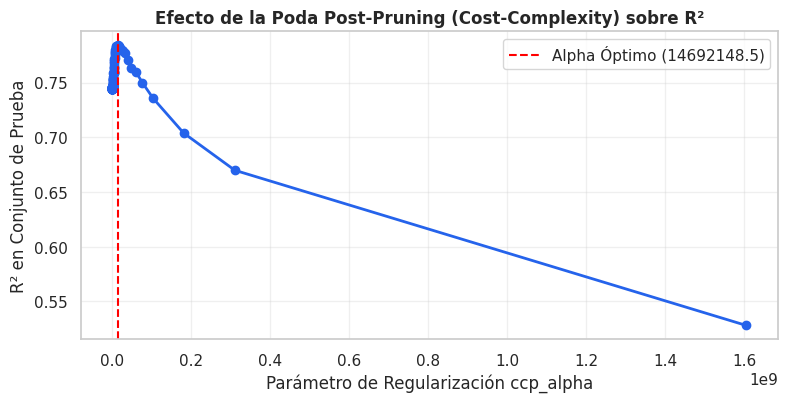

⭐ R² Mejorado en Prueba tras la Poda: 0.7839 (vs. 0.7444 sin podar)


In [6]:
# Submuestreamos alphas para optimización rápida
alphas_a_evaluar = ccp_alphas[::30]
r2_scores_test = []

for a in alphas_a_evaluar:
    t = DecisionTreeRegressor(random_state=42, ccp_alpha=a)
    t.fit(X_train, y_train)
    r2_scores_test.append(t.score(X_test, y_test))

mejor_alpha = alphas_a_evaluar[np.argmax(r2_scores_test)]
mejor_r2    = max(r2_scores_test)

plt.figure(figsize=(9, 4))
plt.plot(alphas_a_evaluar, r2_scores_test, marker='o', color='#2563eb', lw=2)
plt.axvline(mejor_alpha, color='red', linestyle='--', label=f'Alpha Óptimo ({mejor_alpha:.1f})')
plt.xlabel('Parámetro de Regularización ccp_alpha')
plt.ylabel('R² en Conjunto de Prueba')
plt.title('Efecto de la Poda Post-Pruning (Cost-Complexity) sobre R²', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"⭐ R² Mejorado en Prueba tras la Poda: {mejor_r2:.4f} (vs. {tree_overfit.score(X_test, y_test):.4f} sin podar)")

---
## 6. Caso Práctico 2: Optimización y Poda en Cáncer de Mama (*Breast Cancer*) 🩺

Implementamos la partición estocástica manual y la búsqueda de profundidad óptima sobre el conjunto de datos de diagnóstico de cáncer de mama (*UCI ML Breast Cancer Wisconsin*):

Dimensiones Train Cáncer: (448, 30)
Dimensiones Test Cáncer : (121, 30)


DecisionTreeClassifier(max_depth=3, random_state=42)


⭐ Mejor profundidad para Cáncer: 3
Exactitud en Prueba (Cáncer)   : 91.74%


<Figure size 1400x600 with 0 Axes>

[Text(0.5, 0.875, 'worst area <= 868.2\ngini = 0.478\nsamples = 448\nvalue = [177, 271]\nclass = benign'),
 Text(0.25, 0.625, 'worst concave points <= 0.151\ngini = 0.182\nsamples = 296\nvalue = [30, 266]\nclass = benign'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'worst concave points <= 0.132\ngini = 0.071\nsamples = 273\nvalue = [10, 263]\nclass = benign'),
 Text(0.0625, 0.125, 'gini = 0.031\nsamples = 252\nvalue = [4, 248]\nclass = benign'),
 Text(0.1875, 0.125, 'gini = 0.408\nsamples = 21\nvalue = [6, 15]\nclass = benign'),
 Text(0.375, 0.375, 'worst texture <= 23.2\ngini = 0.227\nsamples = 23\nvalue = [20, 3]\nclass = malignant'),
 Text(0.3125, 0.125, 'gini = 0.375\nsamples = 4\nvalue = [1, 3]\nclass = benign'),
 Text(0.4375, 0.125, 'gini = 0.0\nsamples = 19\nvalue = [19, 0]\nclass = malignant'),
 Text(0.75, 0.625, 'texture error <= 0.455\ngini = 0.064\nsamples = 152\nvalue = [147, 5]\nclass = malignant'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'texture error

Text(0.5, 1.0, 'Árbol de Decisión Óptimo para Diagnóstico de Cáncer (depth=3)')

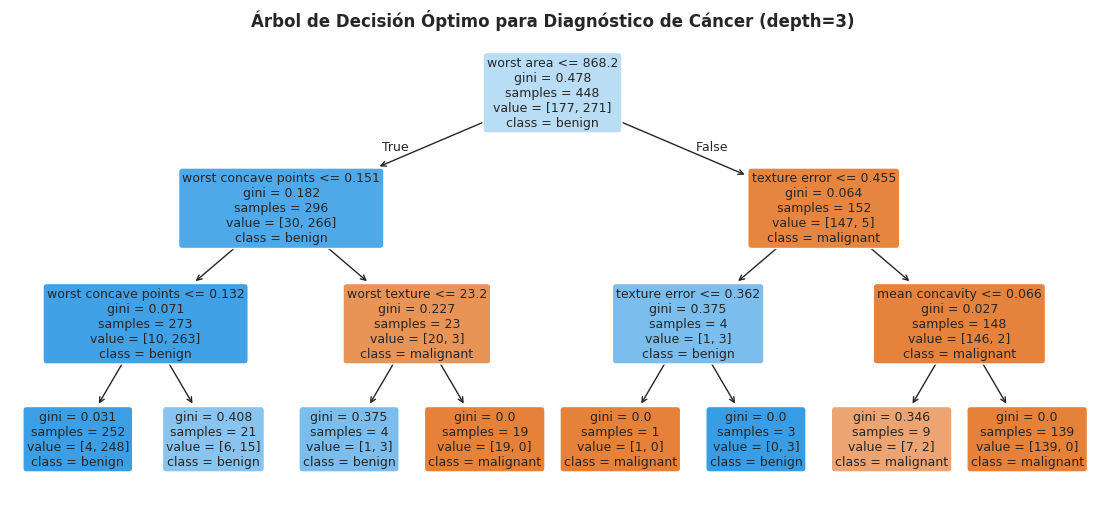

In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score

# 1. Carga de datos
datos_cancer = load_breast_cancer()
X_cancer = datos_cancer.data
y_cancer = datos_cancer.target

# 2. Partición manual 80/20 con máscara booleana uniforme
np.random.seed(40)
test_prop = 0.20
uniform_samples = np.random.uniform(0, 1, len(X_cancer))
msk_cancer = uniform_samples > test_prop

x_tr_c, y_tr_c = X_cancer[msk_cancer],  y_cancer[msk_cancer]
x_ts_c, y_ts_c = X_cancer[~msk_cancer], y_cancer[~msk_cancer]

print(f"Dimensiones Train Cáncer: {x_tr_c.shape}")
print(f"Dimensiones Test Cáncer : {x_ts_c.shape}")

# 3. Evaluación de profundidades de 1 a 10 con 5-Fold CV
profundidades_cancer = list(range(1, 11))
scores_cancer = {}

for d in profundidades_cancer:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    sc = cross_val_score(m, x_tr_c, y_tr_c, cv=5, scoring='accuracy', n_jobs=-1)
    scores_cancer[d] = sc.mean()

mejor_d_cancer = sorted(scores_cancer, key=scores_cancer.get, reverse=True)[0]

# 4. Ajuste del modelo óptimo y evaluación
modelo_cancer_opt = DecisionTreeClassifier(max_depth=mejor_d_cancer, random_state=42)
modelo_cancer_opt.fit(x_tr_c, y_tr_c)
acc_cancer_ts = modelo_cancer_opt.score(x_ts_c, y_ts_c)

print(f"\n⭐ Mejor profundidad para Cáncer: {mejor_d_cancer}")
print(f"Exactitud en Prueba (Cáncer)   : {acc_cancer_ts * 100:.2f}%")

# 5. Gráfico de árbol compacto podado
plt.figure(figsize=(14, 6), dpi=100)
plot_tree(modelo_cancer_opt, feature_names=datos_cancer.feature_names, class_names=datos_cancer.target_names, filled=True, rounded=True, fontsize=9)
plt.title(f"Árbol de Decisión Óptimo para Diagnóstico de Cáncer (depth={mejor_d_cancer})", fontweight='bold')
plt.show()

---
## 7. Resumen y Conclusiones del Cuaderno 02 📌

1. **Predicción Continua:** Los árboles de regresión asignan la media local de las muestras en cada hoja, minimizando el MSE o devianza Poisson.
2. **El Peligro del Sobreajuste:** Un árbol sin podar alcanza un ajuste perfecto en entrenamiento memorizando puntos individuales, lo que arruina su capacidad de generalización.
3. **Poda Cost-Complexity:** La regularización post-poda $R_\alpha(T) = R(T) + \alpha |T|$ penaliza la cantidad de hojas y poda ramas superfluas, incrementando sustancialmente el $R^2$ y la precisión en datos nuevos.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Programación para Ciencia de Datos</i>
  </p>
</div>